# 01 — Data Exploration (EDA)

Goals:
- Load raw ILPD dataset and inspect its structure
- Check for missing values, duplicates, and class balance
- Visualise feature distributions, **class-stratified boxplots**, and outliers
- Save a cleaned dataset for downstream notebooks

All preprocessing (imputation, scaling, encoding) is intentionally deferred to
model pipelines to prevent data leakage.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import get_project_paths, ILPD_COLUMNS
from src.data import load_raw_ilpd, create_basic_clean_dataset, get_class_distribution
from src.plots import (
    save_class_distribution_plot,
    save_missing_values_plot,
    save_correlation_heatmap,
    save_boxplots_by_class,
    save_outlier_summary,
)

In [3]:
paths = get_project_paths()
raw_data_path      = paths["raw_data_path"]
processed_data_path = paths["processed_data_path"]
tables_dir  = paths["tables_dir"]
figures_dir = paths["figures_dir"]
print("Raw data path:", raw_data_path)

Raw data path: C:\lfd_project\data\raw\ilpd.csv


## 1. Load raw dataset

In [4]:
df = load_raw_ilpd(raw_data_path)
print("Shape:", df.shape)
df.head()

Shape: (583, 11)


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Proteins              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Selector                    583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


## 2. Summary statistics

In [6]:
stats = df.describe().T
stats.to_csv(tables_dir / "summary_statistics.csv")
stats

,count,mean,std,min,25%,50%,75%,max
Age,583.0,44.746141,16.189833,4.0,33.0,45.00,58.0,90.0
Total_Bilirubin,583.0,3.298799,6.209522,0.4,0.8,1.00,2.6,75.0
Direct_Bilirubin,583.0,1.486106,2.808498,0.1,0.2,0.30,1.3,19.7
Alkaline_Phosphotase,583.0,290.576329,242.937989,63.0,175.5,208.00,298.0,2110.0
Alamine_Aminotransferase,583.0,80.713551,182.620356,10.0,23.0,35.00,60.5,2000.0
Aspartate_Aminotransferase,583.0,109.910806,288.918529,10.0,25.0,42.00,87.0,4929.0
Total_Proteins,583.0,6.483190,1.085451,2.7,5.8,6.60,7.2,9.6
Albumin,583.0,3.141852,0.795519,0.9,2.6,3.10,3.8,5.5
Albumin_and_Globulin_Ratio,579.0,0.947064,0.319592,0.3,0.7,0.93,1.1,2.8
Selector,583.0,1.286449,0.452490,1.0,1.0,1.00,2.0,2.0


## 3. Missing value analysis

> **Note:** Although the UCI dataset page states no missing values exist, the actual
> CSV contains **4 missing entries in `Albumin_and_Globulin_Ratio`**. These are
> left here intentionally — they will be handled via median imputation *inside*
> each model pipeline after the train-test split, to prevent data leakage.

Missing values found:
                   Feature  Missing Count
Albumin_and_Globulin_Ratio              4


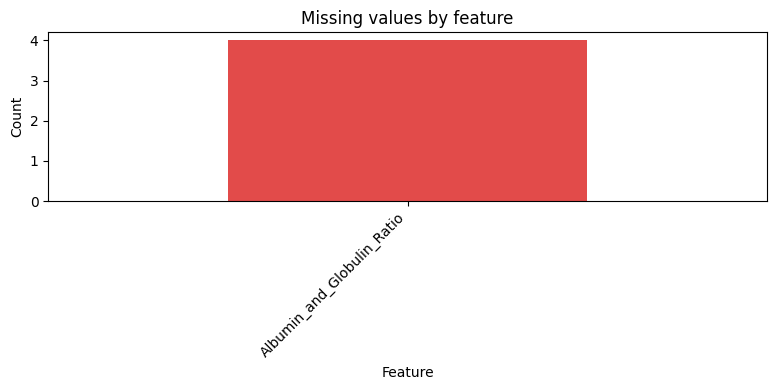

In [7]:
missing = df.isnull().sum()
missing_table = missing[missing > 0].rename("missing_count").reset_index()
missing_table.columns = ["Feature", "Missing Count"]
missing_table.to_csv(tables_dir / "missing_values.csv", index=False)
print("Missing values found:")
print(missing_table.to_string(index=False))

if not missing_table.empty:
    save_missing_values_plot(
        missing_table.set_index("Feature")["Missing Count"],
        figures_dir,
    )

## 4. Duplicate rows

In [8]:
n_dup = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dup}")
dup_rows = df[df.duplicated(keep=False)]
dup_rows.to_csv(tables_dir / "duplicate_rows.csv", index=False)
dup_rows.head()

Exact duplicate rows: 13


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Selector
18,40,Female,0.9,0.3,293,232,245,6.8,3.1,0.8,1
19,40,Female,0.9,0.3,293,232,245,6.8,3.1,0.8,1
25,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.1,1
26,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.1,1
33,38,Female,2.6,1.2,410,59,57,5.6,3.0,0.8,2


## 5. Class distribution

                      count  proportion
No liver disease (0)    167    0.286449
Liver disease (1)       416    0.713551


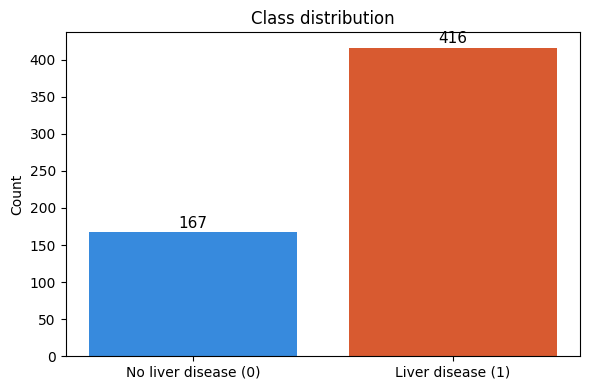

In [9]:
from src.data import prepare_binary_target, split_features_target

df_binary = prepare_binary_target(df)
class_counts = df_binary["target"].value_counts().sort_index()
class_props  = df_binary["target"].value_counts(normalize=True).sort_index()

dist_df = pd.DataFrame({"count": class_counts, "proportion": class_props})
dist_df.index = ["No liver disease (0)", "Liver disease (1)"]
dist_df.to_csv(tables_dir / "class_distribution.csv")
print(dist_df.to_string())

save_class_distribution_plot(class_counts, figures_dir)

## 6. Gender distribution

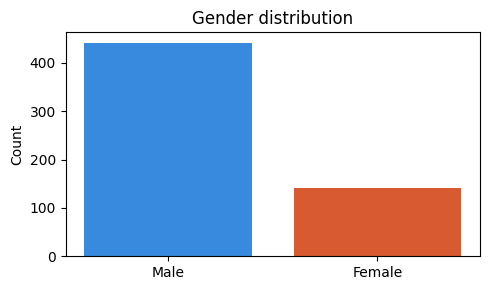

In [10]:
gender_dist = df["Gender"].value_counts().rename("count").reset_index()
gender_dist.columns = ["Gender", "Count"]
gender_dist.to_csv(tables_dir / "gender_distribution.csv", index=False)

plt.figure(figsize=(5, 3))
plt.bar(gender_dist["Gender"], gender_dist["Count"], color=["#378ADD", "#D85A30"])
plt.title("Gender distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(figures_dir / "gender_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Numerical feature distributions

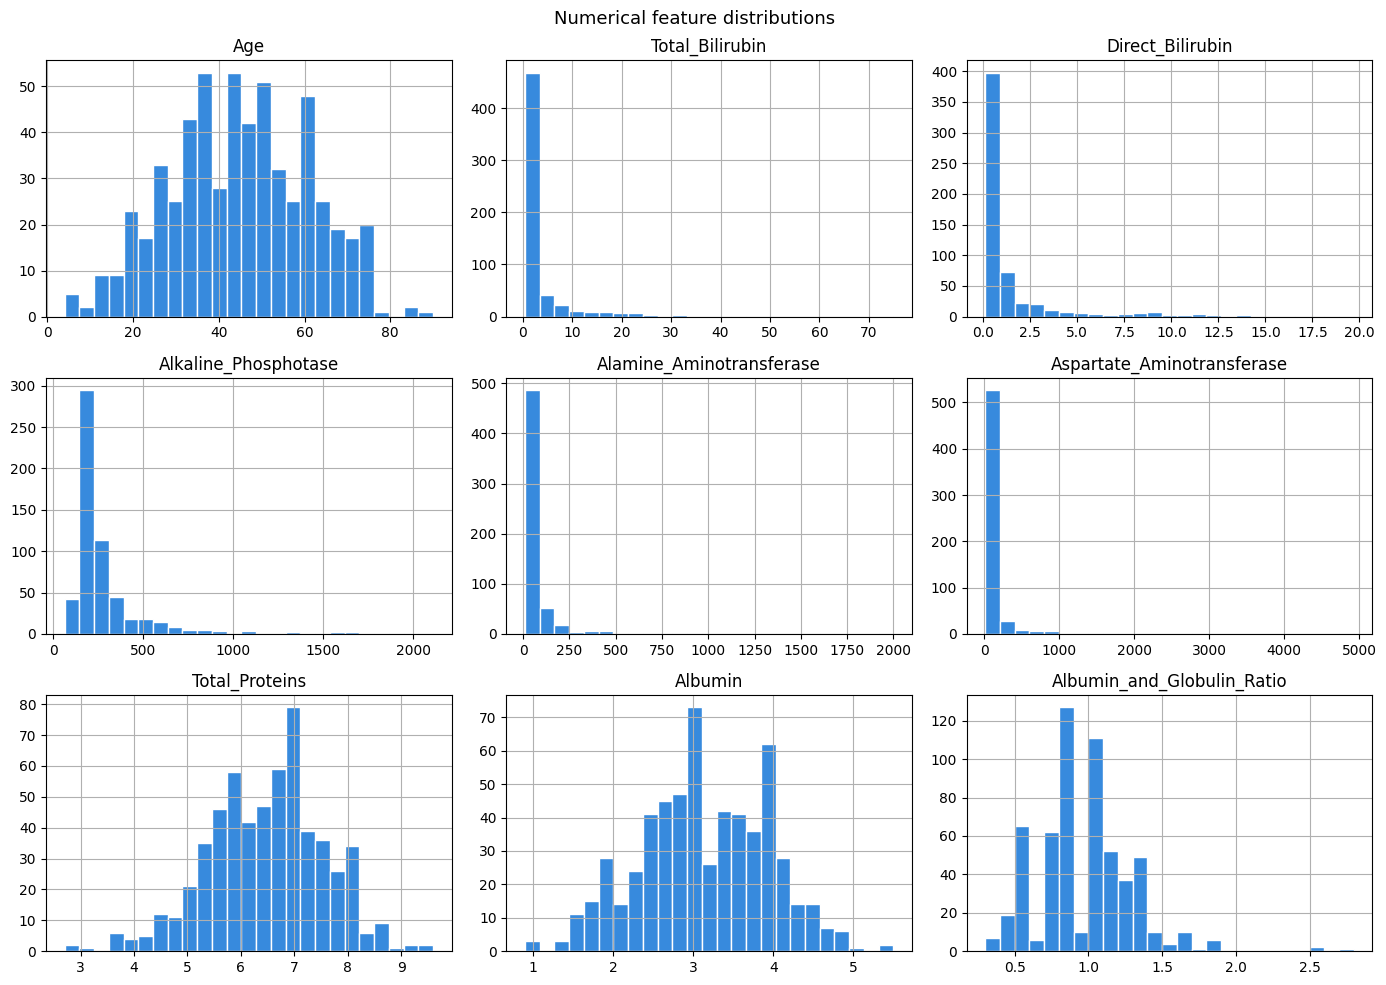

In [11]:
num_cols = [c for c in df.columns if c not in ("Gender", "Selector")]
df[num_cols].hist(figsize=(14, 10), bins=25, color="#378ADD", edgecolor="white")
plt.suptitle("Numerical feature distributions", fontsize=13)
plt.tight_layout()
plt.savefig(figures_dir / "numerical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Class-stratified feature distributions

Boxplots split by target class reveal which features discriminate liver disease
patients from healthy controls. High separation suggests strong predictive value.

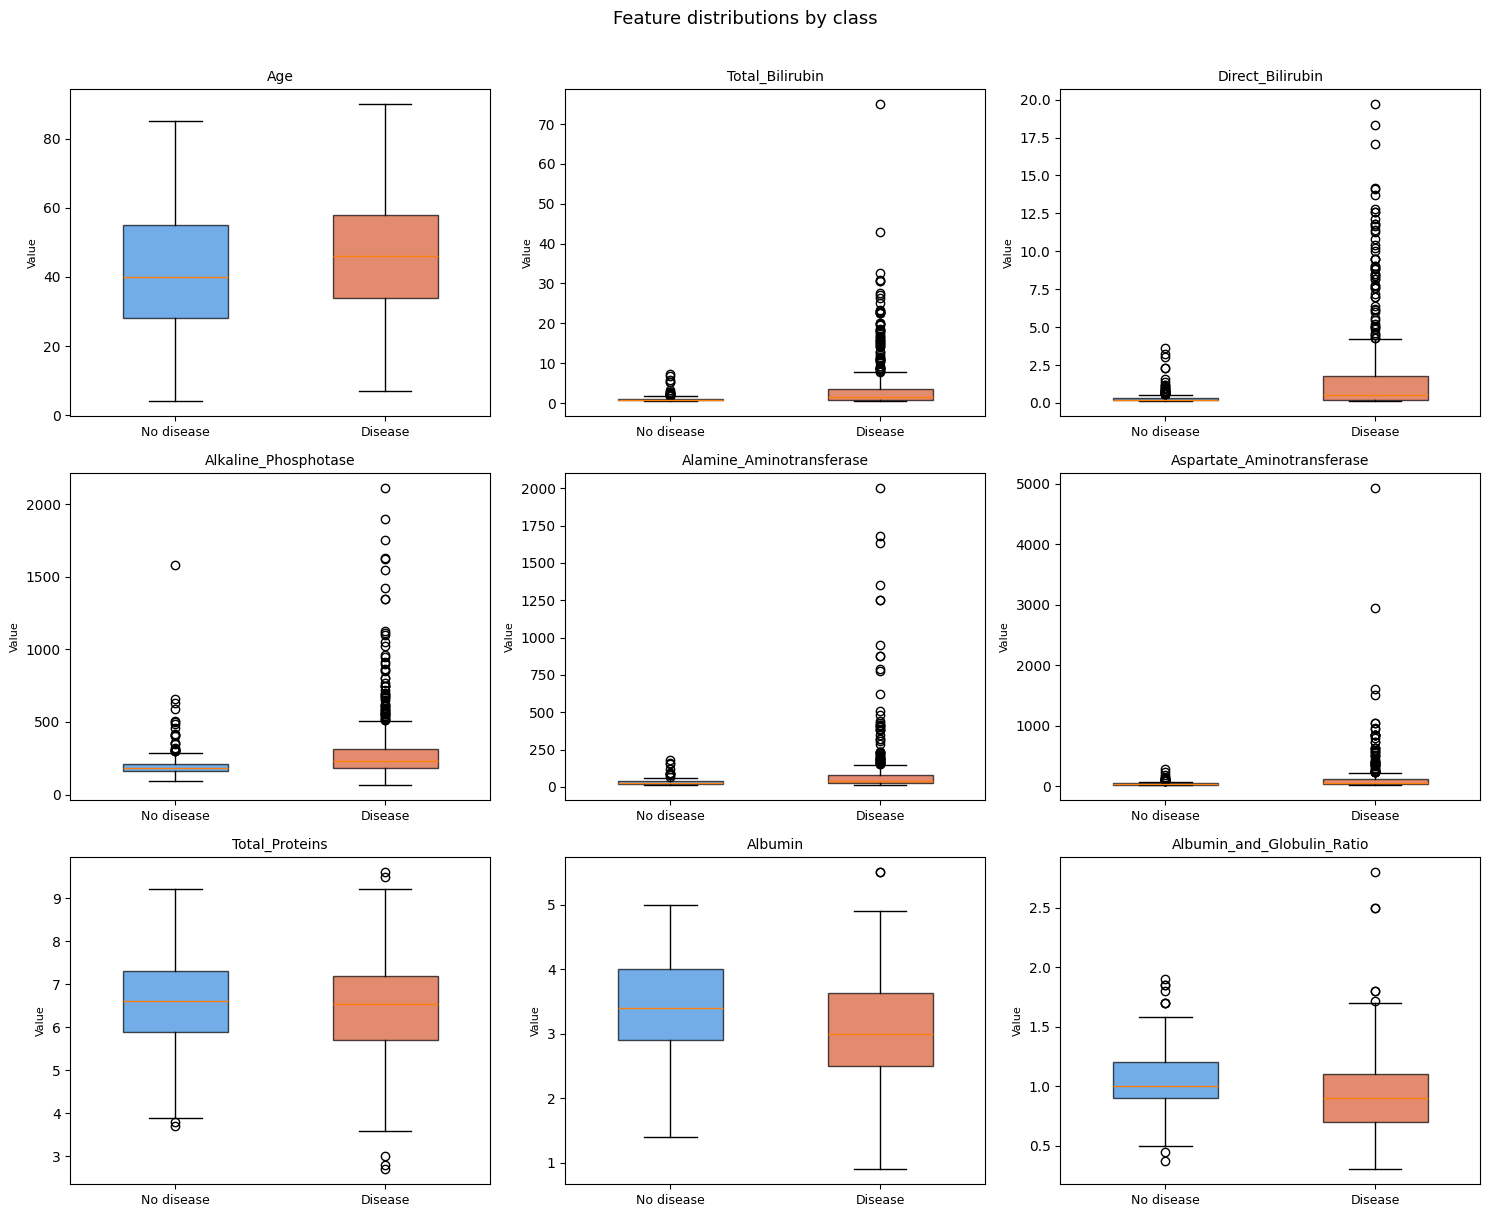

In [12]:
save_boxplots_by_class(
    df_binary,
    target_col="target",
    figures_dir=figures_dir,
    file_name="boxplots_by_class.png",
)

## 9. Outlier analysis (IQR rule)

Counts of values outside [Q1 − 1.5 × IQR, Q3 + 1.5 × IQR].
Liver biochemistry markers are known to have heavy right tails in diseased patients.

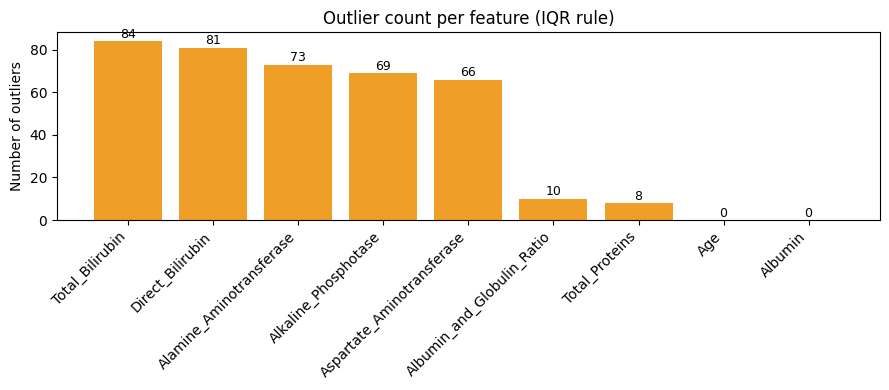

,Feature,Outlier Count
0,Total_Bilirubin,84
1,Direct_Bilirubin,81
2,Alamine_Aminotransferase,73
3,Alkaline_Phosphotase,69
4,Aspartate_Aminotransferase,66
5,Albumin_and_Globulin_Ratio,10
6,Total_Proteins,8
7,Age,0
8,Albumin,0


In [13]:
outlier_counts = save_outlier_summary(df, figures_dir)
outlier_table = outlier_counts.reset_index()
outlier_table.columns = ["Feature", "Outlier Count"]
outlier_table.to_csv(tables_dir / "outlier_counts.csv", index=False)
outlier_table

## 10. Correlation matrix

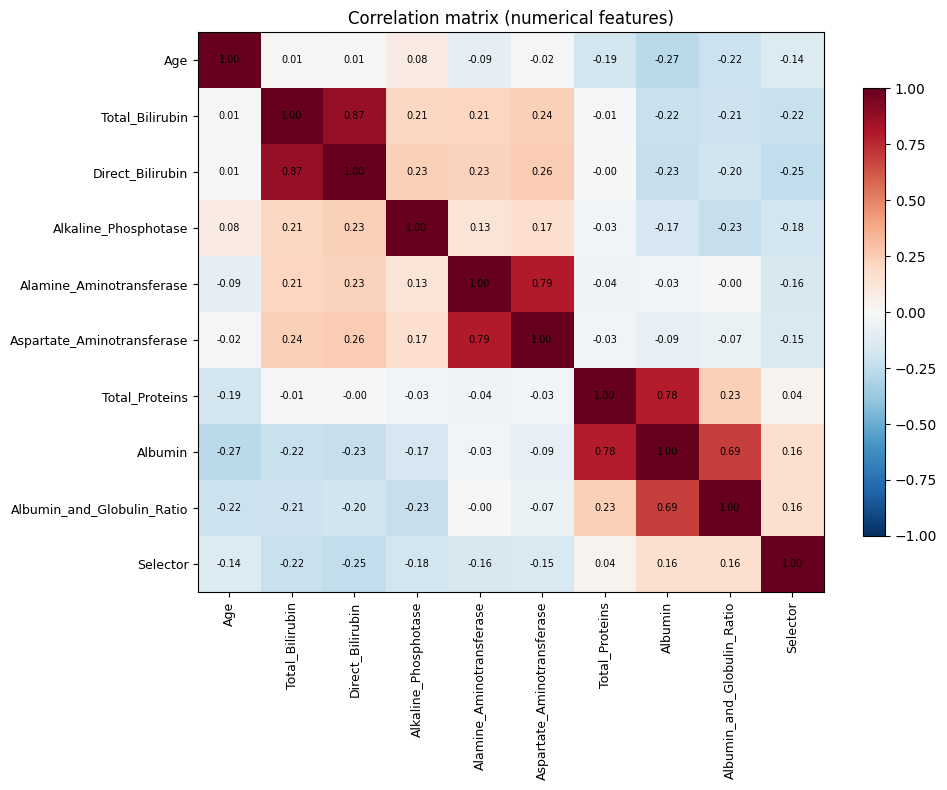

In [14]:
save_correlation_heatmap(df, figures_dir)

## 11. Save processed dataset

In [15]:
df_clean = create_basic_clean_dataset(df, drop_duplicates=True)
print("Original shape:", df.shape)
print("Cleaned shape :", df_clean.shape)
df_clean.to_csv(processed_data_path, index=False)
print("Saved →", processed_data_path)

Original shape: (583, 11)
Cleaned shape : (570, 11)
Saved → C:\lfd_project\data\processed\ilpd_clean.csv


## Summary

Key observations:
- **583 samples**, 416 liver-disease / 167 healthy (~71 % / 29 %): class imbalance
- **4 missing values** in `Albumin_and_Globulin_Ratio` — handled in pipelines
- Bilirubin and enzyme features show heavy right skew with many outliers
- Class-stratified boxplots confirm that bilirubin and SGPT/SGOT separate classes

These findings motivate stratified splitting, multiple metrics (not only accuracy),
imbalance-handling experiments (class weights, SMOTE), and median imputation in pipelines.